## 속도비교

In [14]:
!pip -q install ultralytics

In [15]:
import os, time, math, random, requests
from io import BytesIO
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torchvision
from torchvision.transforms import functional as F
from ultralytics import YOLO

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## (과제) 모델 불러오기: 빈칸 채우기

코드 사이의 빈칸을 채워가면서, 아래 두 질문에 답해주세요

(gpt 안 쓰고 풀면 도움 많이 될 거야..)


In [17]:
# Faster R-CNN (torchvision)
frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
).to(device).eval()

# YOLO (ultralytics) - YOLOv8n
yolo = YOLO("yolov8n.pt")  # 작은 모델이라 속도 비교에 좋음

In [18]:
urls = [
    "https://ultralytics.com/images/bus.jpg",
    "https://ultralytics.com/images/zidane.jpg"
]

pil_imgs = []
for url in urls:
    img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
    pil_imgs.append(img)

len(pil_imgs), pil_imgs[0]

(2, <PIL.Image.Image image mode=RGB size=810x1080>)

In [19]:
def resize_pil(img: Image.Image, size: int) -> Image.Image:
    """Speed benchmark용: 비율 유지 없이 (size, size)로 리사이즈"""
    return img.resize((size, size), Image.BILINEAR)

@torch.no_grad()
def time_faster_rcnn(model, pil_imgs, size: int, warmup: int = 5, runs: int = 30):
    """torchvision Faster R-CNN: ms/img, FPS 측정"""
    batch_cpu = [F.to_tensor(resize_pil(im, size)).to(device) for im in pil_imgs]

    # Warmsup
    for _ in range(warmup):
        batch = [x.to(device, non_blocking=True) for x in batch_cpu]
        _ = model(batch)
    if device == "cuda":
        torch.cuda.synchronize()

    # runs
    t0 = time.perf_counter()
    for _ in range(runs):
        batch = [x.to(device, non_blocking=True) for x in batch_cpu]
        _ = model(batch)
    if device == "cuda":
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    total = (t1 - t0)
    n_imgs = runs * len(batch)
    sec_per_img = total / n_imgs
    ms_per_img = sec_per_img * 1000
    fps = 1.0 / sec_per_img
    return ms_per_img, fps

@torch.no_grad()
def time_yolo(model, pil_imgs, size: int, warmup: int = 5, runs: int = 30, conf: float = 0.25, iou: float = 0.7):
    """ultralytics YOLO: ms/img, FPS 측정 (predict 포함)"""
    imgs = [np.array(resize_pil(im, size)) for im in pil_imgs]

    # warmup
    for _ in range(warmup):
        _ = model.predict(imgs, imgsz=size, conf=conf, iou=iou, verbose=False)
    if device == "cuda":
        torch.cuda.synchronize()

    # runs
    t0 = time.perf_counter()
    for _ in range(runs):
        _ = model.predict(imgs, imgsz=size, conf=conf, iou=iou, verbose=False)
    if device == "cuda":
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    total = (t1 - t0)
    n_imgs = runs * len(imgs)
    sec_per_img = total / n_imgs
    ms_per_img = sec_per_img * 1000
    fps = 1.0 / sec_per_img
    return ms_per_img, fps

def benchmark(models: dict, pil_imgs, sizes=(416, 608), runs: int = 30, warmup: int = 5):
    """
    models: {'name': ('frcnn'|'yolo', model)}
    반환: df (Model, Input Size, ms/img, FPS(img/s))
    """
    rows = []
    for s in sizes:
        for name, (mtype, model) in models.items():
            if mtype == "frcnn":
                ms, fps = time_faster_rcnn(model, pil_imgs, size=s, warmup=warmup, runs=runs)
            elif mtype == "yolo":
                ms, fps = time_yolo(model, pil_imgs, size=s, warmup=warmup, runs=runs)
            else:
                raise ValueError(f"Unknown model type: {mtype}")

            rows.append({"Model": name, "Input Size": f"{s}x{s}", "ms/img": ms, "FPS(img/s)": fps})

    return pd.DataFrame(rows)

In [20]:
# 해상도별 속도 비교 설정
sizes = [416, 608]
runs = 30            # 측정 반복 횟수
warmup = 5

models = {
    "Faster R-CNN (R50-FPN)": ("frcnn", frcnn),
    "YOLO": ("yolo", yolo),
}

df = benchmark(models, pil_imgs, sizes=sizes, runs=runs, warmup=warmup)
df


,Model,Input Size,ms/img,FPS(img/s)
0,Faster R-CNN (R50-FPN),416x416,88.538108,11.294572
1,YOLO,416x416,10.186123,98.172778
2,Faster R-CNN (R50-FPN),608x608,78.688714,12.708303
3,YOLO,608x608,5.394044,185.389658


In [21]:
# FPS 비교 표 (모델 x 해상도)
fps_table = df.pivot(index="Model", columns="Input Size", values="FPS(img/s)").round(2)
ms_table  = df.pivot(index="Model", columns="Input Size", values="ms/img").round(2)

display(fps_table)
display(ms_table)


Input Size,416x416,608x608
Model,,
Faster R-CNN (R50-FPN),11.29,12.71
YOLO,98.17,185.39


Input Size,416x416,608x608
Model,,
Faster R-CNN (R50-FPN),88.54,78.69
YOLO,10.19,5.39


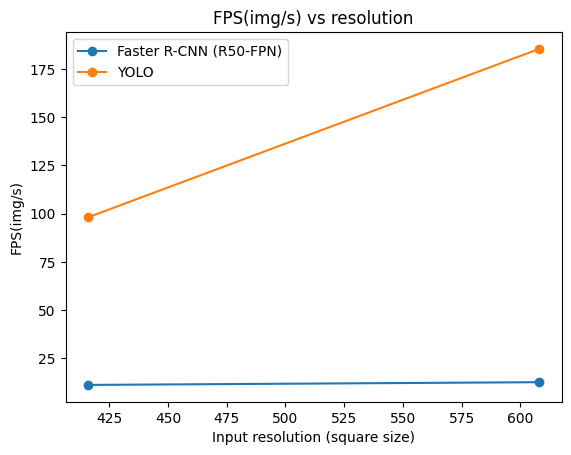

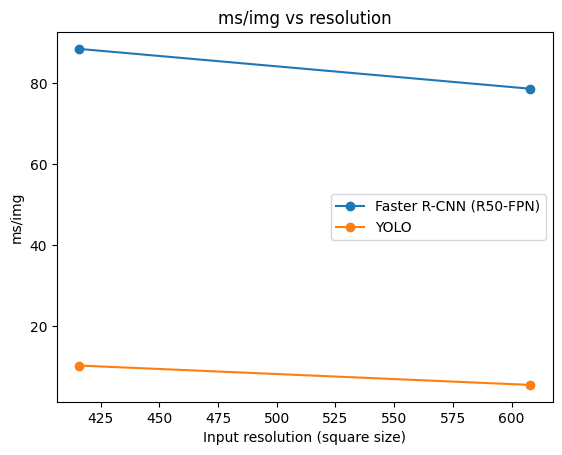

In [22]:
# 시각화

import matplotlib.pyplot as plt

df_plot = df.copy()
df_plot["Size"] = df_plot["Input Size"].str.split("x").str[0].astype(int)

for metric in ["FPS(img/s)", "ms/img"]:
    plt.figure()
    for m in df_plot["Model"].unique():
        sub = df_plot[df_plot["Model"] == m].sort_values("Size")
        plt.plot(sub["Size"], sub[metric], marker="o", label=m)
    plt.xlabel("Input resolution (square size)")
    plt.ylabel(metric)
    plt.title(f"{metric} vs resolution")
    plt.legend()
    plt.show()


## 결과 비교

In [23]:
os.makedirs("vis", exist_ok=True)


In [24]:
from PIL import Image, ImageDraw, ImageFont

def draw_boxes_pil(
    img: Image.Image,
    boxes,        # Tensor or list로 표시
    scores=None,
    labels=None,
    score_thr=0.5
):
    draw = ImageDraw.Draw(img)

    for i, box in enumerate(boxes):
        if scores is not None and scores[i] < score_thr:
            continue

        x1, y1, x2, y2 = box

        draw.rectangle(
            [(x1, y1), (x2, y2)],
            outline= 'red',   # 색 지정
            width=2       # 선 두께
        )

        if labels is not None:
            text = f"{labels[i]}: {scores[i]:.2f}"      # label + score
            draw.text(
                (x1, y1),
                text,
                fill= 'red' # 색
            )

    return img

In [25]:
@torch.no_grad()
def run_frcnn_and_draw(model, pil_img, size=416):
    img_rs = resize_pil(pil_img, size)
    x = F.to_tensor(img_rs).to(device)

    pred = model([x])[0]
    boxes  = pred["boxes"].cpu().numpy()
    scores = pred["scores"].cpu().numpy()
    labels = pred["labels"].cpu().numpy()

    label_names = [
        torchvision.models.detection
        .FasterRCNN_ResNet50_FPN_Weights
        .DEFAULT.meta["categories"][l]
        for l in labels
    ]

    vis = draw_boxes_pil(
        img_rs,
        boxes,
        scores=scores,
        labels=label_names,
        score_thr=0.5
    )
    return vis


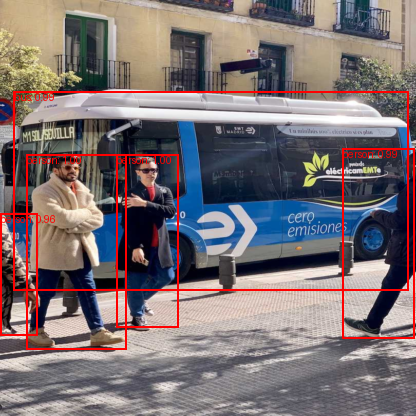

In [26]:
#아래 결과가 나오면 됩니다!!

run_frcnn_and_draw(frcnn, pil_imgs[0], size=416)

# 문제문제

### Q1.
위에서 나온 결과표를 바탕으로, Faster R-CNN과 YOLO 속도 차이를 요약해보세요. 이때 해상도가 증가할수록 두 모델의 속도가 어떻게 변하는지도 설명해주세요.

Ans.

YOLO가 더 빠름.
416x416 해상도에서는 Faster R-CNN에 비해 약 3-5배 정도 FPS가 빨랐고,
608x608 해상도에서는 약 5-8배 빠른 것으로 보임.

해상도가 높아질 수록 Faster R-CNN은 ms/img가 증가하면서 속도가 크게 감소하지만, YOLO는 상대적으로 속도 저하가 적었음.

### Q2.
결과를 확인해보면 Faster R-CNN과 YOLO는 해상도 변화에 따라 받아들이는 정도가 다릅니다. 그 이유에 대해 모델 구조/전처리 관점에서 2가지 가설을 세워보세요.

Ans.

**가설 1. 모델 구조 관점**

Faster R-CNN은 2-stage 구조로 RPN에서 region proposal을 생성한 후, 각 proposal마다 RoI pooling과 classification을 수행함.

해상도가 증가하면 제안되는 region 수가 증가하고, 각 region에 대한 처리 비용이 누적되어 속도가 크게 저하됨.

YOLO는 1-stage 구조로 이미지 전체를 한 번에 처리하여 grid cell 기반으로 직접 예측함. 해상도 증가 시 grid 수는 증가하지만, region proposal 단계가 없어 연산량 증가폭이 상대적으로 작음.



---


**가설 2. 전처리 관점**

Faster R-CNN은 FPN을 사용해서 다양한 scale의 feature map을 생성하고 처리함.
입력 해상도가 증가하면 모든 pyramid level에서 feature map 크기가 증가하여 연산량이 크게 증가함.

YOLO는 경량화된 backbone(YOLOv8n)과 효율적인 feature extraction을 위해 설계되었고, 입력 크기에 따라 동적으로 stride를 조정하는 등 해상도 변화에 강한 구조를 가지고 있음.